In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point
from mpl_toolkits.basemap import Basemap

In [2]:
dirseas5='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'
dirseas5

'/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'

In [3]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
dirfig

'/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'

# Here we show special case including march forecast

In [4]:
dir_wanom='/nf1/predict/AWH017_ABID_ASPECT/weighted_merged_data/with_march/anomaly/indices/'
#dir_wanom

In [5]:
index_merge0=xr.open_dataset(dir_wanom+'merge0_index.nc')
#index_merge0

In [6]:
index_merge1=xr.open_dataset(dir_wanom+'merge1_index.nc')
#index_merge1

In [7]:
index_merge2=xr.open_dataset(dir_wanom+'merge2_index.nc')
#index_merge2

In [8]:
index_merge3=xr.open_dataset(dir_wanom+'merge3_index.nc')
#index_merge3

In [9]:
index_merge4=xr.open_dataset(dir_wanom+'merge4_index.nc')
#index_merge4

In [10]:
index_merge5=xr.open_dataset(dir_wanom+'merge5_index.nc')
#index_merge5

In [11]:
index_merge6=xr.open_dataset(dir_wanom+'merge6_index.nc')
#index_merge6

In [12]:
index_merge7=xr.open_dataset(dir_wanom+'merge7_index.nc')
#index_merge7

In [13]:
index_merge8=xr.open_dataset(dir_wanom+'merge8_index.nc')
#index_merge8

# detreneded merged forecasts

In [14]:
dir_dtd_new_index='/nf1/predict/AWH017_ABID_ASPECT/detrend_merged_weights/weights/anomaly/'

In [15]:
dindex_merge1=xr.open_dataset(dir_dtd_new_index+'index_anomaly_merge1.nc')
#dindex_merge1

In [16]:
dindex_merge4=xr.open_dataset(dir_dtd_new_index+'index_anomaly_merge4.nc')
dindex_merge4

<xarray.Dataset> Size: 11kB
Dimensions:  (member: 66, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 528B 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 11kB ...

In [17]:
dindex_merge8=xr.open_dataset(dir_dtd_new_index+'index_anomaly_merge8.nc')
dindex_merge8

<xarray.Dataset> Size: 16kB
Dimensions:  (member: 91, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 728B 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 15kB ...

In [18]:
dir_dtd_new_index_withoutmarch='/nf1/predict/AWH017_ABID_ASPECT/detrend_merged_weights/weights/anomaly/'
dir_dtd_new_index_withoutmarch

'/nf1/predict/AWH017_ABID_ASPECT/detrend_merged_weights/weights/anomaly/'

In [19]:
index_merge1_nomarch=xr.open_dataset(dir_dtd_new_index_withoutmarch+'index_anomaly_merge1.nc')
index_merge1_nomarch

<xarray.Dataset> Size: 3kB
Dimensions:  (member: 15, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 120B 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 2kB ...

In [20]:
index_merge4_nomarch=xr.open_dataset(dir_dtd_new_index_withoutmarch+'index_anomaly_merge4.nc')
index_merge4_nomarch

<xarray.Dataset> Size: 11kB
Dimensions:  (member: 66, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 528B 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 11kB ...

In [21]:
# Trended merged

In [22]:
anom_ensmean_index_merge0=np.mean(index_merge0.fd[:,0:40],axis = 0)
anom_ensmean_index_merge0

anom_ensmean_index_merge1=np.mean(index_merge1.fd[:,0:40],axis = 0)
anom_ensmean_index_merge1

anom_ensmean_index_merge2=np.mean(index_merge2.fd[:,0:40],axis = 0)
anom_ensmean_index_merge2

anom_ensmean_index_merge3=np.mean(index_merge3.fd[:,0:40],axis = 0)
anom_ensmean_index_merge3

anom_ensmean_index_merge4=np.mean(index_merge4.fd[:,0:40],axis = 0)
anom_ensmean_index_merge4

anom_ensmean_index_merge5=np.mean(index_merge5.fd[:,0:40],axis = 0)
anom_ensmean_index_merge5

anom_ensmean_index_merge6=np.mean(index_merge6.fd[:,0:40],axis = 0)
anom_ensmean_index_merge6


anom_ensmean_index_merge7=np.mean(index_merge7.fd[:,0:40],axis = 0)
anom_ensmean_index_merge7

anom_ensmean_index_merge8=np.mean(index_merge8.fd[:,0:40],axis = 0)
anom_ensmean_index_merge8

<xarray.DataArray 'fd' (time: 40)> Size: 160B
array([ 0.02350979,  0.36547616,  0.19794016,  0.04456951,  0.1179905 ,
        0.05565162,  0.05043288, -0.02522175, -0.04684221,  0.02091328,
        0.17343117,  0.06917837,  0.13369155,  0.1390775 , -0.01034825,
       -0.11859053,  0.03136716, -0.05916028, -0.10325589, -0.11661831,
       -0.09433809, -0.00726486,  0.15782534, -0.01759287, -0.26101273,
       -0.13588548,  0.02808879, -0.02087678,  0.02116597, -0.07499876,
       -0.16050671, -0.14993665, -0.12852687, -0.0993331 , -0.18249755,
       -0.1619569 , -0.24453332, -0.36229783, -0.23375532, -0.35996637],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30

# detrended merged (with march)

In [23]:
danom_ensmean_index_merge1=index_merge1.fd.mean(dim='member')
danom_ensmean_index_merge1

danom_ensmean_index_merge4=index_merge4.fd.mean(dim='member')
danom_ensmean_index_merge4

danom_ensmean_index_merge8=index_merge8.fd.mean(dim='member')
danom_ensmean_index_merge8

<xarray.DataArray 'fd' (time: 40)> Size: 160B
array([ 0.02350979,  0.36547616,  0.19794016,  0.04456951,  0.1179905 ,
        0.05565162,  0.05043288, -0.02522175, -0.04684221,  0.02091328,
        0.17343117,  0.06917837,  0.13369155,  0.1390775 , -0.01034825,
       -0.11859053,  0.03136716, -0.05916028, -0.10325589, -0.11661831,
       -0.09433809, -0.00726486,  0.15782534, -0.01759287, -0.26101273,
       -0.13588548,  0.02808879, -0.02087678,  0.02116597, -0.07499876,
       -0.16050671, -0.14993665, -0.12852687, -0.0993331 , -0.18249755,
       -0.1619569 , -0.24453332, -0.36229783, -0.23375532, -0.35996637],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30

# detrended merged (without march)

In [24]:
danom_ensmean_index_nomarch_merge1=index_merge1_nomarch.fd.mean(dim='member')
danom_ensmean_index_nomarch_merge1

danom_ensmean_index_nomarch_merge4=index_merge4_nomarch.fd.mean(dim='member')
danom_ensmean_index_nomarch_merge4

<xarray.DataArray 'fd' (time: 40)> Size: 160B
array([-4.99775186e-02,  6.15926795e-02,  4.73868512e-02,  5.57945669e-02,
        3.32985781e-02, -9.44478288e-02,  6.03460073e-02,  4.20464985e-02,
       -8.59779119e-02, -6.88561872e-02,  5.97510934e-02,  1.16160735e-01,
       -9.92538035e-03, -1.39232567e-02, -4.81974036e-02, -1.95032135e-02,
       -9.67543200e-02,  4.50515673e-02, -5.32797128e-02, -4.44318447e-03,
        1.27181280e-02,  1.61959484e-01, -2.48669777e-02, -9.55420583e-02,
       -9.86461192e-02,  8.39458331e-02, -3.93561497e-02, -1.42755359e-02,
        2.46363616e-05, -4.50217910e-02, -1.50857540e-02,  1.95326339e-02,
        3.77460942e-02,  4.07249741e-02, -7.10229203e-02, -5.98816723e-02,
        5.07021956e-02,  1.88859680e-03,  7.10559189e-02, -1.98444091e-02],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30

# ERA5 dataset [Detrend]

In [25]:
masktopo=xr.open_dataset(dirfig+'finalmask_new_notopsea.nc')
maskfo=masktopo.where((masktopo.latitude>25)&(masktopo.latitude<80),drop=True)
maskfo_1=maskfo.topo
maskfo_1

<xarray.DataArray 'topo' (latitude: 219, longitude: 1437)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 876B 79.75 79.5 79.25 ... 25.75 25.5 25.25
    time       datetime64[ns] 8B 1981-01-01T01:00:00

In [26]:
det_era5='/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/marapr/'
det_era5

'/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/marapr/'

In [27]:
era5_maap_dtd=xr.open_dataset(det_era5+'maapfdall_era5_detd.nc')
era5_maap_dtd_1=era5_maap_dtd.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
era5_maap_dtd_1=era5_maap_dtd_1.where((era5_maap_dtd_1.latitude>25)&(era5_maap_dtd_1.latitude<80),drop=True)


In [28]:
era5_maap_dtd_2=era5_maap_dtd_1.sel(time=slice(datetime(1983,1,1),datetime(2016,12,31)))
mean_era5_dtd_1=era5_maap_dtd_2.frost_days_index_per_time_period.groupby('time.month').mean()


In [29]:
anom_era5_ma_dtd=era5_maap_dtd_1.frost_days_index_per_time_period.groupby('time.month')-mean_era5_dtd_1


# ERA5 Index (trend vs detrend)

In [30]:
anom_obsmaap_freqts_dtd=Adtools.data_sub(anom_era5_ma_dtd*maskfo.topo,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
anom_obsmaap_freqts_dtd


anom_obsmaap_freqts_dtd_1 = anom_obsmaap_freqts_dtd.weighted(
   np.cos(np.deg2rad(anom_obsmaap_freqts_dtd.latitude))).mean(('longitude','latitude'))

anom_obsmaap_freqts_dtd_1

<xarray.DataArray (time: 40)> Size: 160B
array([-1.3784585 ,  3.6623144 ,  1.5219808 ,  0.08417208, -0.7954885 ,
        1.0095797 , -1.6904254 ,  0.11298247, -1.492691  , -0.58553386,
        1.4560288 , -1.6501116 ,  0.08143031, -0.21129923, -2.0649104 ,
       -0.4151077 , -0.13190944, -0.9319901 , -1.1966968 , -1.501587  ,
       -1.4414732 ,  2.352556  ,  4.904275  , -0.5134285 , -0.61292344,
        0.00934293, -0.841323  ,  3.7257671 , -0.33102414, -0.6490203 ,
        0.6516318 , -0.6963949 , -0.58278555,  0.1425211 , -0.7340262 ,
        0.60520524, -0.9791734 , -0.7599193 , -0.5325127 , -0.04089386],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
    month    (time) int64 320B 4 4 4 4 4 4 4 4 4 4 4 4 ... 4 4 4 4 4 4 4 4 4 4 4

In [31]:
dirindices='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'

era5_index_1=xr.open_dataset(dirindices+'era5_anom_obsmaap_freqts_index_1.nc')
#era5_index_1.fd.values

# Prediction skill for the March-April season [Trend vs Detrend]

In [32]:
skill_m0=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge0)
skill_m1=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge1)
skill_m2=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge2)
skill_m3=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge3)
skill_m4=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge4)
skill_m5=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge5)
skill_m6=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge6)
skill_m7=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge7)
skill_m8=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_merge8)
#skill_m8

In [33]:
skillmatrix_maap_trend=[skill_m0.rvalue,skill_m1.rvalue,skill_m2.rvalue, skill_m3.rvalue,skill_m4.rvalue, skill_m5.rvalue,skill_m6.rvalue,skill_m7.rvalue, skill_m8.rvalue]
#skillmatrix_maap_trend

# Skill for detrended with march

In [34]:
skill_dtd_merge1=stats.pearsonr(danom_ensmean_index_merge1, anom_obsmaap_freqts_dtd_1)
skill_dtd_merge1

skill_dtd_merge4=stats.pearsonr(danom_ensmean_index_merge4, anom_obsmaap_freqts_dtd_1)
skill_dtd_merge4

skill_dtd_merge8=stats.pearsonr(danom_ensmean_index_merge8, anom_obsmaap_freqts_dtd_1)
skill_dtd_merge8

PearsonRResult(statistic=0.41791114, pvalue=0.0072895416692075315)

In [35]:
skillmatrix_detrend_merged=[0,skill_dtd_merge1.statistic, skill_dtd_merge1.statistic,skill_dtd_merge1.statistic,skill_dtd_merge4.statistic,skill_dtd_merge4.statistic,skill_dtd_merge4.statistic,skill_dtd_merge4.statistic,skill_dtd_merge8.statistic]
skillmatrix_detrend_merged

[0,
 0.11343102,
 0.11343102,
 0.11343102,
 0.058578994,
 0.058578994,
 0.058578994,
 0.058578994,
 0.41791114]

# Skill for detrended without march

In [36]:

nomarch_skill_dtd_merge1=stats.pearsonr(danom_ensmean_index_nomarch_merge1, anom_obsmaap_freqts_dtd_1)
nomarch_skill_dtd_merge1


nomarch_skill_dtd_merge4=stats.pearsonr(danom_ensmean_index_nomarch_merge4, anom_obsmaap_freqts_dtd_1)
nomarch_skill_dtd_merge4

PearsonRResult(statistic=0.16683696, pvalue=0.3035059727335034)

In [37]:
skillmatrix_detrend_merged_nomarch=[0,nomarch_skill_dtd_merge1.statistic, nomarch_skill_dtd_merge1.statistic,nomarch_skill_dtd_merge1.statistic,nomarch_skill_dtd_merge4.statistic,nomarch_skill_dtd_merge4.statistic,nomarch_skill_dtd_merge4.statistic,nomarch_skill_dtd_merge4.statistic]
skillmatrix_detrend_merged_nomarch

[0,
 0.17382647,
 0.17382647,
 0.17382647,
 0.16683696,
 0.16683696,
 0.16683696,
 0.16683696]

In [38]:
from scipy.stats import bootstrap
rng = np.random.default_rng()

In [39]:
def corr(x,  y):
    return stats.pearsonr(x,y)[0]

In [53]:
trendlow_ci=[]
trendhigh_ci=[]

merge_data = {
    "merge0": anom_ensmean_index_merge0,
    "merge1": anom_ensmean_index_merge1,
    "merge2": anom_ensmean_index_merge2,
    "merge3": anom_ensmean_index_merge3,
    "merge4": anom_ensmean_index_merge4,
    "merge5": anom_ensmean_index_merge5,
    "merge6": anom_ensmean_index_merge6,
    "merge7": anom_ensmean_index_merge7,
    "merge8": anom_ensmean_index_merge8,}

results = {}

for name, data in merge_data.items():
    res = bootstrap((era5_index_1.fd, data),corr,paired=True,n_resamples=10000,method='basic',vectorized=False)
    
    trendlow_ci.append(res.confidence_interval.low)
    trendhigh_ci.append(res.confidence_interval.high)

#    print(f"{name}: " f"low={res.confidence_interval.low:.2f}, " f"high={res.confidence_interval.high:.2f}")

trendlow_ci = np.array(trendlow_ci)
trendhigh_ci = np.array(trendhigh_ci)
#print("Low CI:", trendlow_ci)
#print("High CI:", trendhigh_ci)

In [42]:
#result

In [43]:
# Here is the skill without march and Jan in merging

In [51]:
wskill_Withoutmarch=[0.2402027300927922,
 0.3064982849238391,
 0.30085912499985523,
 0.28444834463691904,
 0.27784015469919804,
 0.26699705289643116,
 0.26699705289643116,
 0.24970754036304466]

In [45]:
wlow_ci=array([-0.02537778,  0.01920758,  0.02458324, -0.01379362, -0.03658581,
        -0.04498183, -0.05651118, -0.05743035])

In [46]:
whigh_ci=array([0.53430202, 0.5904118 , 0.57671163, 0.57371631, 0.60374439,
        0.57791278, 0.57789027, 0.57170202])

In [48]:
#wskillmerge

Text(0, 0.5, 'Forecast Skill')

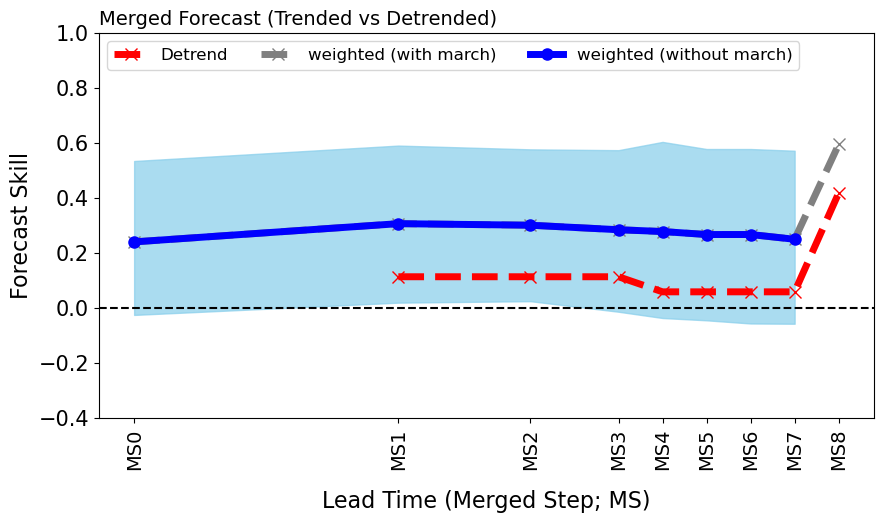

In [52]:
f,ax = plt.subplots(1,1,figsize=[10,5])
#ax2 = ax.twinx()

leadtime=np.arange(17)
leadtime2=np.array([leadtime[0],leadtime[6],leadtime[9],leadtime[11],leadtime[12],leadtime[13],leadtime[14],leadtime[15],leadtime[16]])
leadtime2

ftz=14

ci=0.05
#ax2.set_ylim([0,300])

ax.set_ylim([-0.4,1])
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=15)

ax.set_xticks(leadtime2)

ax.set_xticklabels( ('MS0', 'MS1','MS2','MS3','MS4','MS5','MS6','MS7','MS8' ))

ax.tick_params(axis='x', labelrotation=90)

leadtime3=np.array([leadtime[0],leadtime[6],leadtime[9],leadtime[11],leadtime[12],leadtime[13],leadtime[14],leadtime[15],leadtime[16]])

ax.plot(leadtime3[1:],skillmatrix_detrend_merged[1:],color='red',label='Detrend',linestyle='dashed',marker='x',markersize=8,linewidth=5,zorder=10)

ax.plot(leadtime3,skillmatrix_maap_trend,color='grey',label='weighted (with march)',linestyle='dashed',marker='x',markersize=9,linewidth=5,zorder=10)

#ax2.set_ylabel('Ensemble size', fontsize=16)

ax.plot(leadtime3[:-1],wskill_Withoutmarch,color='blue',label='weighted (without march)',linestyle='solid',marker='o',markersize=8,linewidth=5,zorder=10)
ax.fill_between(leadtime3[:-1],wlow_ci,whigh_ci,alpha=0.7,color='skyblue')#,label='shading95%')

ax.axhline(0,linestyle='dashed',color='black')
ax.legend(fontsize=12,loc='upper left',ncols=3)

ax.set_title('Merged Forecast (Trended vs Detrended)',fontsize=14,loc='left')

ax.set_xlabel('Lead Time (Merged Step; MS)',fontsize=16, labelpad=15)
ax.set_ylabel('Forecast Skill', fontsize=16)


#plt.savefig(dirfig+"revisedV2_fig6_trend_vs_detrend_weighted.png",dpi=300, bbox_inches='tight')